# Votes Prediction

Let's import the necessary libraries



In [4]:
import pandas as pd

import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# For models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


Importing the dataset "votacoes_com_llm_pop.csv"

In [5]:
df = pd.read_csv('votacoes_com_llm_pop.csv')
df.tail(5)

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,...,idDeputadoAutor,nomeAutor,data_ref,legislatura,author_prev_community,prev_community_0_size,prev_community_1_size,prev_community_2_size,classified_llm,authors_pop
78813,347421-224,2024-12-19,180,PLEN,1.0,358,129,1,Mantido o texto. Sim: 358; Não: 129; Abstenção...,2024,...,74345.0,Evandro Milhomen,1889,57,NaN,441.0,155.0,0,NaN,NaN
78814,347421-224,2024-12-19,180,PLEN,1.0,358,129,1,Mantido o texto. Sim: 358; Não: 129; Abstenção...,2024,...,141451.0,Ilderlei Cordeiro,1889,57,NaN,441.0,155.0,0,NaN,NaN
78815,347421-224,2024-12-19,180,PLEN,1.0,358,129,1,Mantido o texto. Sim: 358; Não: 129; Abstenção...,2024,...,141539.0,Sebastião Bala Rocha,1889,57,NaN,441.0,155.0,0,NaN,NaN
78816,347421-224,2024-12-19,180,PLEN,1.0,358,129,1,Mantido o texto. Sim: 358; Não: 129; Abstenção...,2024,...,141386.0,Eudes Xavier,1889,57,NaN,441.0,155.0,0,NaN,NaN
78817,2473375-80,2024-12-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo relator...,2024,...,160674.0,Hugo Motta,1889,57,0.0,441.0,155.0,0,Approval of Final Wording,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78818 entries, 0 to 78817
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     78818 non-null  object 
 1   data                   78818 non-null  object 
 2   idOrgao                78818 non-null  int64  
 3   siglaOrgao             78818 non-null  object 
 4   aprovacao              78818 non-null  float64
 5   votosSim               78818 non-null  int64  
 6   votosNao               78818 non-null  int64  
 7   votosOutros            78818 non-null  int64  
 8   descricao              78818 non-null  object 
 9   ano                    78818 non-null  int64  
 10  proposicao_id          78818 non-null  int64  
 11  proposicao_ementa      78818 non-null  object 
 12  id_proposicao          78818 non-null  float64
 13  tema                   78818 non-null  object 
 14  orientacao_GOV         78818 non-null  object 
 15  ti

Let's keep only the columns we need:

id
aprovacao
tema
orientacao_GOV
tipoAutor
idDeputadoAutor
legislatura
author_prev_community
prev_community_0_size
prev_community_1_size
prev_community_2_size
classified_llm
authors_pop

In [7]:
columns_to_keep = [
    'id',
    'idDeputadoAutor',
    'legislatura',
    'data',
    'tema',
    'orientacao_GOV',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
    'classified_llm',
    'authors_pop',
    'aprovacao'
]

df = df[columns_to_keep]
df.tail()


,id,idDeputadoAutor,legislatura,data,tema,orientacao_GOV,author_prev_community,prev_community_0_size,prev_community_1_size,prev_community_2_size,classified_llm,authors_pop,aprovacao
78813,347421-224,74345.0,57,2024-12-19,Finanças Públicas e Orçamento,Sim,NaN,441.0,155.0,0,NaN,NaN,1.0
78814,347421-224,141451.0,57,2024-12-19,Finanças Públicas e Orçamento,Sim,NaN,441.0,155.0,0,NaN,NaN,1.0
78815,347421-224,141539.0,57,2024-12-19,Finanças Públicas e Orçamento,Sim,NaN,441.0,155.0,0,NaN,NaN,1.0
78816,347421-224,141386.0,57,2024-12-19,Finanças Públicas e Orçamento,Sim,NaN,441.0,155.0,0,NaN,NaN,1.0
78817,2473375-80,160674.0,57,2024-12-19,Previdência e Assistência Social,Neutro,0.0,441.0,155.0,0,Approval of Final Wording,NaN,1.0


In [8]:
# Drop rows with NaN in any of the specified columns before converting to int64
cols_to_int = [
    'idDeputadoAutor',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
    'aprovacao'
]

df = df.dropna(subset=cols_to_int)
for col in cols_to_int:
    df[col] = df[col].astype('int64')


In [9]:
df['data'] = pd.to_datetime(df['data'], format='%Y-%m-%d')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43399 entries, 5644 to 78817
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     43399 non-null  object        
 1   idDeputadoAutor        43399 non-null  int64         
 2   legislatura            43399 non-null  int64         
 3   data                   43399 non-null  datetime64[ns]
 4   tema                   43399 non-null  object        
 5   orientacao_GOV         43399 non-null  object        
 6   author_prev_community  43399 non-null  int64         
 7   prev_community_0_size  43399 non-null  int64         
 8   prev_community_1_size  43399 non-null  int64         
 9   prev_community_2_size  43399 non-null  int64         
 10  classified_llm         16767 non-null  object        
 11  authors_pop            8319 non-null   float64       
 12  aprovacao              43399 non-null  int64         
dtypes: 

Let's make a feature engineering for Author's Community based on:

Let's create a now column named 'authors_major_comm'

From the column 'author_prev_community' we compare if his community is the biggest or not.

- If the value in 'author_prev_community' is 0 and 'prev_community_0_size' is bigger than 'prev_community_1_size', so 'authors_major_comm' = 1

- If the value in 'author_prev_community' is 1 and 'prev_community_1_size' is bigger than 'prev_community_0_size', so 'authors_major_comm' = 1

- Else: 'authors_major_comm' = 0

In [11]:
def is_major_comm(row):
    if row['author_prev_community'] == 0 and row['prev_community_0_size'] > row['prev_community_1_size']:
        return 1
    elif row['author_prev_community'] == 1 and row['prev_community_1_size'] > row['prev_community_0_size']:
        return 1
    else:
        return 0

df['authors_major_comm'] = df.apply(is_major_comm, axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43399 entries, 5644 to 78817
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     43399 non-null  object        
 1   idDeputadoAutor        43399 non-null  int64         
 2   legislatura            43399 non-null  int64         
 3   data                   43399 non-null  datetime64[ns]
 4   tema                   43399 non-null  object        
 5   orientacao_GOV         43399 non-null  object        
 6   author_prev_community  43399 non-null  int64         
 7   prev_community_0_size  43399 non-null  int64         
 8   prev_community_1_size  43399 non-null  int64         
 9   prev_community_2_size  43399 non-null  int64         
 10  classified_llm         16767 non-null  object        
 11  authors_pop            8319 non-null   float64       
 12  aprovacao              43399 non-null  int64         
 13  aut

In [13]:
columns_to_keep = [
    'id',
    'idDeputadoAutor',
    'legislatura',
    'data',
    'tema',
    'classified_llm',
    'authors_pop', 
    "authors_major_comm",
    'orientacao_GOV',
    'aprovacao'
]

df = df[columns_to_keep]
df.tail()

,id,idDeputadoAutor,legislatura,data,tema,classified_llm,authors_pop,authors_major_comm,orientacao_GOV,aprovacao
78792,347421-215,74165,57,2024-12-19,Finanças Públicas e Orçamento,NaN,NaN,1,Neutro,1
78793,347421-215,141372,57,2024-12-19,Finanças Públicas e Orçamento,NaN,NaN,1,Neutro,1
78794,347421-215,74254,57,2024-12-19,Finanças Públicas e Orçamento,NaN,NaN,1,Neutro,1
78796,347421-215,73808,57,2024-12-19,Finanças Públicas e Orçamento,NaN,NaN,1,Neutro,1
78817,2473375-80,160674,57,2024-12-19,Previdência e Assistência Social,Approval of Final Wording,NaN,1,Neutro,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43399 entries, 5644 to 78817
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  43399 non-null  object        
 1   idDeputadoAutor     43399 non-null  int64         
 2   legislatura         43399 non-null  int64         
 3   data                43399 non-null  datetime64[ns]
 4   tema                43399 non-null  object        
 5   classified_llm      16767 non-null  object        
 6   authors_pop         8319 non-null   float64       
 7   authors_major_comm  43399 non-null  int64         
 8   orientacao_GOV      43399 non-null  object        
 9   aprovacao           43399 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 3.6+ MB


In [15]:
df['classified_llm'] = df['classified_llm'].fillna('no_class')
df['authors_pop'] = df['authors_pop'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43399 entries, 5644 to 78817
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  43399 non-null  object        
 1   idDeputadoAutor     43399 non-null  int64         
 2   legislatura         43399 non-null  int64         
 3   data                43399 non-null  datetime64[ns]
 4   tema                43399 non-null  object        
 5   classified_llm      43399 non-null  object        
 6   authors_pop         43399 non-null  float64       
 7   authors_major_comm  43399 non-null  int64         
 8   orientacao_GOV      43399 non-null  object        
 9   aprovacao           43399 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 3.6+ MB


In [16]:
df.tail()

,id,idDeputadoAutor,legislatura,data,tema,classified_llm,authors_pop,authors_major_comm,orientacao_GOV,aprovacao
78792,347421-215,74165,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1
78793,347421-215,141372,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1
78794,347421-215,74254,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1
78796,347421-215,73808,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1
78817,2473375-80,160674,57,2024-12-19,Previdência e Assistência Social,Approval of Final Wording,0.0,1,Neutro,1


In [17]:
df.to_csv("votacoes_selected.csv", index=False)

In [18]:
votacoes_network = pd.read_csv("votacoes_network.csv")
votacoes_network

,id,idDeputadoAutor,legislatura,data,tema,classified_llm,authors_pop,authors_major_comm,orientacao_GOV,aprovacao,autor_eigenvector_centrality,autor_clustering_coefficient,autor_pagerank,autor_community_id
0,340896-3,74399,53,2007-02-14,Defesa e Segurança,Approval of Requests,0.0,0,Neutro,1,0.007723,0.066571,0.000909,1
1,340896-3,74399,53,2007-02-14,Direito Penal e Processual Penal,Approval of Requests,0.0,0,Neutro,1,0.007723,0.066571,0.000909,1
2,340368-20,74517,53,2007-02-15,"Política, Partidos e Eleições",Change in Processing Regime,0.0,1,Neutro,1,0.043880,0.357156,0.001855,0
3,340368-21,74399,53,2007-02-15,"Política, Partidos e Eleições",Approval of Requests,0.0,0,Neutro,1,0.007723,0.066571,0.000909,1
4,340368-31,74324,53,2007-02-15,"Política, Partidos e Eleições",Approval of Final Wording,0.0,0,Neutro,1,0.039475,0.280483,0.001889,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43394,347421-215,74165,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.051185,0.467471,0.001678,0
43395,347421-215,141372,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.051288,0.468488,0.001678,0
43396,347421-215,74254,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.045476,0.387322,0.001678,0
43397,347421-215,73808,57,2024-12-19,Finanças Públicas e Orçamento,no_class,0.0,1,Neutro,1,0.051143,0.492320,0.001678,0


In [19]:

# Sort the dataframe by the temporal column "data"
df_sorted = votacoes_network.sort_values('data')

# Determine split indices for train, validation, and test sets
# Example: 70% train, 15% validation, 15% test
n = len(df_sorted)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

# Split the data into train, validation, and test sets based on "data"
df_train = df_sorted.iloc[:train_end]
df_val = df_sorted.iloc[train_end:val_end]
df_test = df_sorted.iloc[val_end:]

# Separate features and target, dropping "data" from features
feature_cols = [col for col in votacoes_network.columns if col not in ['aprovacao', 'data', 'idDeputadoAutor', 'id', 'legislatura']]

X_train = df_train[feature_cols]
y_train = df_train['aprovacao']

X_val = df_val[feature_cols]
y_val = df_val['aprovacao']

X_test = df_test[feature_cols]
y_test = df_test['aprovacao']

# Manually specify numerical and categorical columns
numerical_cols = ['authors_pop', 'autor_eigenvector_centrality', 'autor_clustering_coefficient', 'autor_pagerank']
categorical_cols = [col for col in feature_cols if col not in numerical_cols]

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")


Categorical columns: ['tema', 'classified_llm', 'authors_major_comm', 'orientacao_GOV', 'autor_community_id']
Numerical columns: ['authors_pop', 'autor_eigenvector_centrality', 'autor_clustering_coefficient', 'autor_pagerank']
Training set shape: (30379, 9)
Validation set shape: (6510, 9)
Test set shape: (6510, 9)


In [20]:
# Define models to evaluate
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Dictionary to store results
results = {}

# Function to evaluate model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, report, conf_matrix


In [21]:
# Preprocessing: Encode categorical features and scale numerical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Fit the preprocessor on the training data and transform all splits
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
def get_feature_names(preprocessor):
    feature_names = []
    # Numerical features
    if hasattr(preprocessor.named_transformers_['num'], 'get_feature_names_out'):
        feature_names.extend(preprocessor.named_transformers_['num'].get_feature_names_out(numerical_cols))
    else:
        feature_names.extend(numerical_cols)
    # Categorical features
    ohe = preprocessor.named_transformers_['cat']
    if hasattr(ohe, 'get_feature_names_out'):
        feature_names.extend(ohe.get_feature_names_out(categorical_cols))
    else:
        # fallback
        feature_names.extend(categorical_cols)
    return feature_names

processed_feature_names = get_feature_names(preprocessor)

import pandas as pd
X_train_processed = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index)
X_val_processed = pd.DataFrame(X_val_processed, columns=processed_feature_names, index=X_val.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test.index)

# For model training below, use X_train_processed, X_val_processed, X_test_processed


Iniciando busca pelo melhor algoritmo com o melhor F1 score total...

--- Buscando melhores hiperparâmetros para XGBoost ---
Total de combinações: 60
[1/60] Treinando XGBoost com {'classifier__n_estimators': 190, 'classifier__learning_rate': 0.001, 'classifier__max_depth': 3}...


e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


F1 total (macro) na validação: 0.4531
Novo melhor modelo encontrado (maior F1 total)!
[2/60] Treinando XGBoost com {'classifier__n_estimators': 190, 'classifier__learning_rate': 0.001, 'classifier__max_depth': 4}...


e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


F1 total (macro) na validação: 0.4531
[3/60] Treinando XGBoost com {'classifier__n_estimators': 190, 'classifier__learning_rate': 0.001, 'classifier__max_depth': 5}...


...

F1 total (macro) na validação: 0.5924
[3/4] Treinando LogisticRegression com {'classifier__C': 10, 'classifier__solver': 'lbfgs', 'classifier__max_iter': 200}...


e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


F1 total (macro) na validação: 0.5934
[4/4] Treinando LogisticRegression com {'classifier__C': 20, 'classifier__solver': 'lbfgs', 'classifier__max_iter': 200}...


e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


F1 total (macro) na validação: 0.5948

Busca finalizada.
Melhor algoritmo: RandomForest
Melhores parâmetros: {'classifier__n_estimators': 50, 'classifier__max_depth': None}
Melhor F1 total (macro) na validação: 0.6685

Avaliando melhor modelo no validation set...

Melhor Modelo (RandomForest) - Validation Accuracy: 0.8462
Melhor Modelo (RandomForest) - Validation F1 Score (total/macro): 0.6685
Melhor Modelo (RandomForest) - Validation F1 Score (classe 0): 0.4257
Melhor Modelo (RandomForest) - Validation F1 Score (classe 1): 0.9112
Melhor Modelo (RandomForest) - Validation Recall (classe 0): 0.3321
Melhor Modelo (RandomForest) - Validation Recall (classe 1): 0.9527
Melhor Modelo (RandomForest) - Validation ROC AUC: 0.7614
Melhor Modelo (RandomForest) - Validation Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.33      0.43      1117
           1       0.87      0.95      0.91      5393

    accuracy                           0

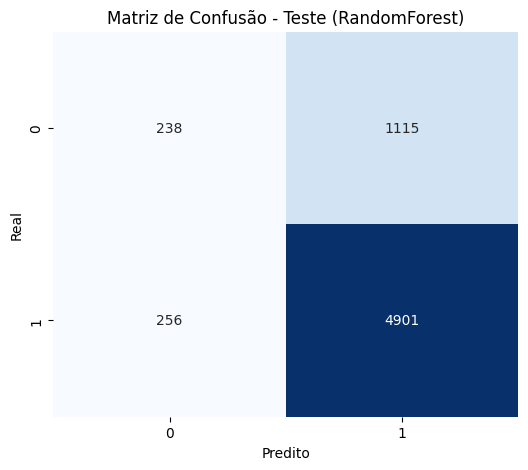

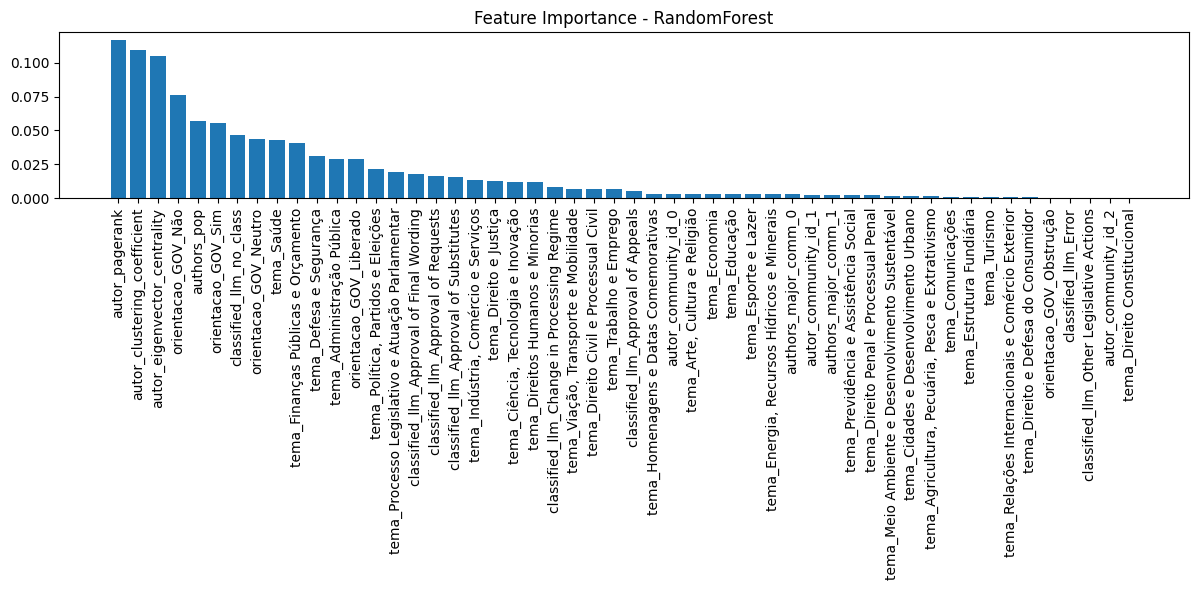


Tabela com os melhores hiperparâmetros de cada algoritmo:


,Algoritmo,Melhor F1 macro validação,Melhores Hiperparâmetros
0,XGBoost,0.637563,"{'classifier__n_estimators': 190, 'classifier_..."
1,RandomForest,0.668469,"{'classifier__n_estimators': 50, 'classifier__..."
2,LogisticRegression,0.594848,"{'classifier__C': 20, 'classifier__solver': 'l..."


In [ ]:
# Encontrar o melhor algoritmo com o melhor F1 score total
from sklearn.metrics import make_scorer, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Iniciando busca pelo melhor algoritmo com o melhor F1 score total...")

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Definir grids de parâmetros para cada algoritmo
param_grids = {
    'XGBoost': {
        'classifier__n_estimators': [190, 200, 210],
        'classifier__learning_rate': [0.001, 0.09, 0.1, 0.15],
        'classifier__max_depth': [3, 4, 5, 6, 7]
    },
    'RandomForest': {
        'classifier__n_estimators': [50, 190, 200, 210],
        'classifier__max_depth': [1, 2, 3, 4, None]
    },
    'LogisticRegression': {
        'classifier__C': [0.1, 1, 10, 20],
        'classifier__solver': ['lbfgs'],
        'classifier__max_iter': [200]
    }
}

# Definir os algoritmos
algorithms = {
    'XGBoost': XGBClassifier(eval_metric='logloss', use_label_encoder=False),
    'RandomForest': RandomForestClassifier(),
    'LogisticRegression': LogisticRegression()
}

from itertools import product
import copy

best_f1_total = -1
best_algo = None
best_params = None
best_model = None

results = {}

# Para armazenar o melhor resultado de cada algoritmo
best_per_algo = {}

for algo_name, clf in algorithms.items():
    print(f"\n--- Buscando melhores hiperparâmetros para {algo_name} ---")
    param_grid = param_grids[algo_name]
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    total_combinacoes = 1
    for v in param_values:
        total_combinacoes *= len(v)
    print(f"Total de combinações: {total_combinacoes}")
    comb_count = 0

    # Para armazenar o melhor resultado deste algoritmo
    best_f1_this_algo = -1
    best_params_this_algo = None
    best_pipeline_this_algo = None

    for param_tuple in product(*param_values):
        comb_count += 1
        params = dict(zip(param_names, param_tuple))
        print(f"[{comb_count}/{total_combinacoes}] Treinando {algo_name} com {params}...")
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', copy.deepcopy(clf))
        ])
        pipeline.set_params(**params)
        pipeline.fit(X_train, y_train)
        y_val_pred = pipeline.predict(X_val)
        y_val_proba = pipeline.predict_proba(X_val)[:, 1] if hasattr(pipeline.named_steps['classifier'], "predict_proba") else None

        # F1 score total (macro)
        val_f1_total = f1_score(y_val, y_val_pred, average='macro')
        val_f1_0 = f1_score(y_val, y_val_pred, pos_label=0)
        val_f1_1 = f1_score(y_val, y_val_pred, pos_label=1)
        val_recall_0 = recall_score(y_val, y_val_pred, pos_label=0)
        val_recall_1 = recall_score(y_val, y_val_pred, pos_label=1)
        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else None
        val_report = classification_report(y_val, y_val_pred)
        val_conf_matrix = confusion_matrix(y_val, y_val_pred)

        print(f"F1 total (macro) na validação: {val_f1_total:.4f}")

        # Atualiza o melhor resultado deste algoritmo
        if val_f1_total > best_f1_this_algo:
            best_f1_this_algo = val_f1_total
            best_params_this_algo = params
            best_pipeline_this_algo = copy.deepcopy(pipeline)

        if val_f1_total > best_f1_total:
            print("Novo melhor modelo encontrado (maior F1 total)!")
            best_f1_total = val_f1_total
            best_algo = algo_name
            best_params = params
            best_model = copy.deepcopy(pipeline)
            best_val_report = val_report
            best_val_conf_matrix = val_conf_matrix
            best_val_accuracy = val_accuracy
            best_val_f1_0 = val_f1_0
            best_val_f1_1 = val_f1_1
            best_val_recall_0 = val_recall_0
            best_val_recall_1 = val_recall_1
            best_val_auc = val_auc

        # Armazenar resultados intermediários
        results[f"{algo_name}_{comb_count}"] = {
            'model': copy.deepcopy(pipeline),
            'params': params,
            'val_f1_total': val_f1_total,
            'val_f1_0': val_f1_0,
            'val_f1_1': val_f1_1,
            'val_accuracy': val_accuracy,
            'val_recall_0': val_recall_0,
            'val_recall_1': val_recall_1,
            'val_auc': val_auc,
            'val_report': val_report,
            'val_conf_matrix': val_conf_matrix
        }

    # Salva o melhor resultado deste algoritmo
    best_per_algo[algo_name] = {
        'best_f1_total': best_f1_this_algo,
        'best_params': best_params_this_algo,
        'best_pipeline': best_pipeline_this_algo
    }

print("\nBusca finalizada.")
print(f"Melhor algoritmo: {best_algo}")
print(f"Melhores parâmetros: {best_params}")
print(f"Melhor F1 total (macro) na validação: {best_f1_total:.4f}")

# Avaliar melhor modelo no validation set
print("\nAvaliando melhor modelo no validation set...")
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model.named_steps['classifier'], "predict_proba") else None

val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_total = f1_score(y_val, y_val_pred, average='macro')
val_f1_0 = f1_score(y_val, y_val_pred, pos_label=0)
val_f1_1 = f1_score(y_val, y_val_pred, pos_label=1)
val_recall_0 = recall_score(y_val, y_val_pred, pos_label=0)
val_recall_1 = recall_score(y_val, y_val_pred, pos_label=1)
val_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else None
val_report = classification_report(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)

print(f"\nMelhor Modelo ({best_algo}) - Validation Accuracy: {val_accuracy:.4f}")
print(f"Melhor Modelo ({best_algo}) - Validation F1 Score (total/macro): {val_f1_total:.4f}")
print(f"Melhor Modelo ({best_algo}) - Validation F1 Score (classe 0): {val_f1_0:.4f}")
print(f"Melhor Modelo ({best_algo}) - Validation F1 Score (classe 1): {val_f1_1:.4f}")
print(f"Melhor Modelo ({best_algo}) - Validation Recall (classe 0): {val_recall_0:.4f}")
print(f"Melhor Modelo ({best_algo}) - Validation Recall (classe 1): {val_recall_1:.4f}")
if val_auc is not None:
    print(f"Melhor Modelo ({best_algo}) - Validation ROC AUC: {val_auc:.4f}")
print(f"Melhor Modelo ({best_algo}) - Validation Classification Report:\n{val_report}")
print(f"Melhor Modelo ({best_algo}) - Validation Confusion Matrix:\n{val_conf_matrix}")

# Avaliar no test set
print("\nAvaliando melhor modelo no test set...")
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model.named_steps['classifier'], "predict_proba") else None

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_total = f1_score(y_test, y_test_pred, average='macro')
test_f1_0 = f1_score(y_test, y_test_pred, pos_label=0)
test_f1_1 = f1_score(y_test, y_test_pred, pos_label=1)
test_recall_0 = recall_score(y_test, y_test_pred, pos_label=0)
test_recall_1 = recall_score(y_test, y_test_pred, pos_label=1)
test_auc = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None
test_report = classification_report(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

print("Resultados no test set calculados.")

# Armazenar resultados finais
results['BestModel'] = {
    'best_model': best_model,
    'best_algo': best_algo,
    'best_params': best_params,
    'val_accuracy': val_accuracy,
    'val_f1_total': val_f1_total,
    'val_f1_0': val_f1_0,
    'val_f1_1': val_f1_1,
    'val_recall_0': val_recall_0,
    'val_recall_1': val_recall_1,
    'val_auc': val_auc,
    'val_report': val_report,
    'val_conf_matrix': val_conf_matrix,
    'test_accuracy': test_accuracy,
    'test_f1_total': test_f1_total,
    'test_f1_0': test_f1_0,
    'test_f1_1': test_f1_1,
    'test_recall_0': test_recall_0,
    'test_recall_1': test_recall_1,
    'test_auc': test_auc,
    'test_report': test_report,
    'test_conf_matrix': test_conf_matrix
}

print(f"\nMelhor Algoritmo: {best_algo}")
print(f"Melhores Parâmetros: {best_params}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score (total/macro): {test_f1_total:.4f}")
print(f"Test F1 Score (classe 0): {test_f1_0:.4f}")
print(f"Test F1 Score (classe 1): {test_f1_1:.4f}")
print(f"Test Recall (classe 0): {test_recall_0:.4f}")
print(f"Test Recall (classe 1): {test_recall_1:.4f}")
if test_auc is not None:
    print(f"Test ROC AUC: {test_auc:.4f}")
print(f"Test Classification Report:\n{test_report}")
print(f"Test Confusion Matrix:\n{test_conf_matrix}")
print("Pipeline de busca pelo melhor algoritmo (F1 total) finalizado.")

# --- GRÁFICOS ---

# 1. Matriz de confusão (test set) - gráfico
plt.figure(figsize=(6,5))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusão - Teste ({best_algo})')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# 2. Feature Importance do melhor modelo - gráfico
# Pega o classificador treinado (após o preprocessor)
clf = best_model.named_steps['classifier']

# Para pegar os nomes das features após o preprocessor:
if hasattr(best_model.named_steps['preprocessor'], 'transformers_'):
    # Tenta pegar nomes das features processadas
    try:
        feature_names = []
        # Numéricas
        num_features = best_model.named_steps['preprocessor'].named_transformers_['num']
        if hasattr(num_features, 'get_feature_names_out'):
            feature_names.extend(num_features.get_feature_names_out(numerical_cols))
        else:
            feature_names.extend(numerical_cols)
        # Categóricas
        cat_features = best_model.named_steps['preprocessor'].named_transformers_['cat']
        if hasattr(cat_features, 'get_feature_names_out'):
            feature_names.extend(cat_features.get_feature_names_out(categorical_cols))
        else:
            feature_names.extend(categorical_cols)
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

importances = None
if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    # Garante que o número de nomes de features bate com o número de importâncias
    if len(feature_names) != len(importances):
        feature_names = [f"feature_{i}" for i in range(len(importances))]
    # Ordena por importância
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(12, 6))
    plt.title(f"Feature Importance - {best_algo}")
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("O melhor modelo não possui atributo de feature importance disponível para plotar.")

# --- TABELA DE MELHORES HIPERPARÂMETROS DE CADA ALGORITMO ---

melhores_algos = []
for algo, info in best_per_algo.items():
    melhores_algos.append({
        'Algoritmo': algo,
        'Melhor F1 macro validação': info['best_f1_total'],
        'Melhores Hiperparâmetros': info['best_params']
    })

df_melhores_algos = pd.DataFrame(melhores_algos)
print("\nTabela com os melhores hiperparâmetros de cada algoritmo:")
df_melhores_algos


In [45]:
# Exibe todas as colunas do DataFrame sem truncar e ajusta a largura máxima de exibição de colunas
with pd.option_context('display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
    print(df_melhores_algos)

            Algoritmo  Melhor F1 macro validação  \
0             XGBoost                   0.637563   
1        RandomForest                   0.668469   
2  LogisticRegression                   0.594848   

                                                                           Melhores Hiperparâmetros  
0  {'classifier__n_estimators': 190, 'classifier__learning_rate': 0.15, 'classifier__max_depth': 3}  
1                                   {'classifier__n_estimators': 50, 'classifier__max_depth': None}  
2                 {'classifier__C': 20, 'classifier__solver': 'lbfgs', 'classifier__max_iter': 200}  


# Baseline Models Evaluation

In this section, we'll implement and evaluate several baseline models for comparison:

1. Random Guess - Randomly assigns 0 or 1 with equal probability
2. Majority Class - Always predicts the most common class from the training set
3. Stratified Probability - Predicts based on the class distribution in the training set
4. Government Recommendation - Uses the government's orientation as a predictor

We'll evaluate these baselines using the same metrics as our machine learning models.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, recall_score, roc_auc_score, classification_report

print("Implementing baseline models for comparison...")

# Store results for comparison
baseline_results = []

# 1. Random Guess Baseline
print("\n1. Random Guess Baseline")
np.random.seed(42)  # For reproducibility
random_preds = np.random.randint(0, 2, size=len(y_test))  # Randomly assign 0 or 1
random_probs = np.random.random(size=len(y_test))  # Random probabilities for ROC AUC

# Evaluate Random Guess
random_accuracy = accuracy_score(y_test, random_preds)
random_f1_total = f1_score(y_test, random_preds, average='macro')
random_f1_0 = f1_score(y_test, random_preds, pos_label=0)
random_f1_1 = f1_score(y_test, random_preds, pos_label=1)
random_recall_0 = recall_score(y_test, random_preds, pos_label=0)
random_recall_1 = recall_score(y_test, random_preds, pos_label=1)
random_auc = roc_auc_score(y_test, random_probs)
random_report = classification_report(y_test, random_preds)
random_conf_matrix = confusion_matrix(y_test, random_preds)

print(f"Random Guess - Accuracy: {random_accuracy:.4f}")
print(f"Random Guess - F1 Score (macro): {random_f1_total:.4f}")
print(f"Random Guess - ROC AUC: {random_auc:.4f}")
print(f"Random Guess - Classification Report:\n{random_report}")

baseline_results.append({
    'model': 'Random Guess',
    'accuracy': random_accuracy,
    'f1_total': random_f1_total,
    'f1_0': random_f1_0,
    'f1_1': random_f1_1,
    'recall_0': random_recall_0,
    'recall_1': random_recall_1,
    'roc_auc': random_auc
})


Implementing baseline models for comparison...

1. Random Guess Baseline
Random Guess - Accuracy: 0.5029
Random Guess - F1 Score (macro): 0.4580
Random Guess - ROC AUC: 0.4921
Random Guess - Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.52      0.30      1353
           1       0.80      0.50      0.61      5157

    accuracy                           0.50      6510
   macro avg       0.51      0.51      0.46      6510
weighted avg       0.68      0.50      0.55      6510



In [23]:
# 2. Majority Class Baseline
print("\n2. Majority Class Baseline")
majority_class = int(y_train.mean() >= 0.5)  # 1 if majority is approved, 0 otherwise
majority_preds = np.full(len(y_test), majority_class)
# For ROC AUC, we'll use a constant probability
majority_probs = np.full(len(y_test), 1.0 if majority_class == 1 else 0.0)

# Evaluate Majority Class
majority_accuracy = accuracy_score(y_test, majority_preds)
majority_f1_total = f1_score(y_test, majority_preds, average='macro')
majority_f1_0 = f1_score(y_test, majority_preds, pos_label=0, zero_division=0)
majority_f1_1 = f1_score(y_test, majority_preds, pos_label=1, zero_division=0)
majority_recall_0 = recall_score(y_test, majority_preds, pos_label=0, zero_division=0)
majority_recall_1 = recall_score(y_test, majority_preds, pos_label=1, zero_division=0)
majority_auc = roc_auc_score(y_test, majority_probs)
majority_report = classification_report(y_test, majority_preds, zero_division=0)
majority_conf_matrix = confusion_matrix(y_test, majority_preds)

print(f"Majority Class - Accuracy: {majority_accuracy:.4f}")
print(f"Majority Class - F1 Score (macro): {majority_f1_total:.4f}")
print(f"Majority Class - ROC AUC: {majority_auc:.4f}")
print(f"Majority Class - Classification Report:\n{majority_report}")

baseline_results.append({
    'model': 'Majority Class',
    'accuracy': majority_accuracy,
    'f1_total': majority_f1_total,
    'f1_0': majority_f1_0,
    'f1_1': majority_f1_1,
    'recall_0': majority_recall_0,
    'recall_1': majority_recall_1,
    'roc_auc': majority_auc
})

# 3. Stratified Probability Baseline
print("\n3. Stratified Probability Baseline")
approval_rate = y_train.mean()
np.random.seed(42)  # Reset seed for reproducibility
stratified_probs = np.random.random(size=len(y_test))  # Generate random numbers
stratified_preds = (stratified_probs < approval_rate).astype(int)  # Convert to binary predictions based on approval rate

# Evaluate Stratified Probability
stratified_accuracy = accuracy_score(y_test, stratified_preds)
stratified_f1_total = f1_score(y_test, stratified_preds, average='macro')
stratified_f1_0 = f1_score(y_test, stratified_preds, pos_label=0)
stratified_f1_1 = f1_score(y_test, stratified_preds, pos_label=1)
stratified_recall_0 = recall_score(y_test, stratified_preds, pos_label=0)
stratified_recall_1 = recall_score(y_test, stratified_preds, pos_label=1)
stratified_auc = roc_auc_score(y_test, stratified_probs)
stratified_report = classification_report(y_test, stratified_preds)
stratified_conf_matrix = confusion_matrix(y_test, stratified_preds)

print(f"Stratified Probability - Accuracy: {stratified_accuracy:.4f}")
print(f"Stratified Probability - F1 Score (macro): {stratified_f1_total:.4f}")
print(f"Stratified Probability - ROC AUC: {stratified_auc:.4f}")
print(f"Stratified Probability - Classification Report:\n{stratified_report}")

baseline_results.append({
    'model': 'Stratified Probability',
    'accuracy': stratified_accuracy,
    'f1_total': stratified_f1_total,
    'f1_0': stratified_f1_0,
    'f1_1': stratified_f1_1,
    'recall_0': stratified_recall_0,
    'recall_1': stratified_recall_1,
    'roc_auc': stratified_auc
})



2. Majority Class Baseline
Majority Class - Accuracy: 0.7922
Majority Class - F1 Score (macro): 0.4420
Majority Class - ROC AUC: 0.5000
Majority Class - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1353
           1       0.79      1.00      0.88      5157

    accuracy                           0.79      6510
   macro avg       0.40      0.50      0.44      6510
weighted avg       0.63      0.79      0.70      6510


3. Stratified Probability Baseline
Stratified Probability - Accuracy: 0.5940
Stratified Probability - F1 Score (macro): 0.4931
Stratified Probability - ROC AUC: 0.4898
Stratified Probability - Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.36      0.27      1353
           1       0.80      0.66      0.72      5157

    accuracy                           0.59      6510
   macro avg       0.50      0.51      0.49      6510
weighte

In [24]:
# 4. Government Recommendation Baseline
print("\n4. Government Recommendation Baseline")

# Define a mapping for government recommendations
gov_rec_map = {
    'Sim': 1,    # Yes -> Approve
    'Não': 0,    # No -> Reject
    'Obstrução': 0,  # Obstruction -> Reject
    'Liberado': None,  # Liberated -> No recommendation
    'Neutro': None  # Neutral -> No recommendation
}

# Apply the mapping
gov_preds = []
gov_probs = []

for _, row in X_test.iterrows():
    rec = row['orientacao_GOV']
    if pd.isna(rec) or rec not in gov_rec_map or gov_rec_map[rec] is None:
        # If no clear recommendation, use the approval rate from training data
        pred_prob = approval_rate
        pred = 1 if np.random.random() < approval_rate else 0
    else:
        # Follow the government's recommendation
        pred = gov_rec_map[rec]
        pred_prob = 1.0 if pred == 1 else 0.0
    
    gov_preds.append(pred)
    gov_probs.append(pred_prob)

gov_preds = np.array(gov_preds)
gov_probs = np.array(gov_probs)

# Evaluate Government Recommendation
gov_accuracy = accuracy_score(y_test, gov_preds)
gov_f1_total = f1_score(y_test, gov_preds, average='macro')
gov_f1_0 = f1_score(y_test, gov_preds, pos_label=0)
gov_f1_1 = f1_score(y_test, gov_preds, pos_label=1)
gov_recall_0 = recall_score(y_test, gov_preds, pos_label=0)
gov_recall_1 = recall_score(y_test, gov_preds, pos_label=1)
gov_auc = roc_auc_score(y_test, gov_probs)
gov_report = classification_report(y_test, gov_preds)
gov_conf_matrix = confusion_matrix(y_test, gov_preds)

print(f"Government Recommendation - Accuracy: {gov_accuracy:.4f}")
print(f"Government Recommendation - F1 Score (macro): {gov_f1_total:.4f}")
print(f"Government Recommendation - ROC AUC: {gov_auc:.4f}")
print(f"Government Recommendation - Classification Report:\n{gov_report}")

baseline_results.append({
    'model': 'Government Recommendation',
    'accuracy': gov_accuracy,
    'f1_total': gov_f1_total,
    'f1_0': gov_f1_0,
    'f1_1': gov_f1_1,
    'recall_0': gov_recall_0,
    'recall_1': gov_recall_1,
    'roc_auc': gov_auc
})



4. Government Recommendation Baseline
Government Recommendation - Accuracy: 0.6873
Government Recommendation - F1 Score (macro): 0.5910
Government Recommendation - ROC AUC: 0.7008
Government Recommendation - Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.49      0.39      1353
           1       0.85      0.74      0.79      5157

    accuracy                           0.69      6510
   macro avg       0.59      0.61      0.59      6510
weighted avg       0.74      0.69      0.71      6510



In [25]:
# Create a DataFrame to compare all results (baselines + ML models)
print("\n## Comparison of All Models")

# Extract relevant metrics from results dict
ml_model_results = [{
    'model': results['BestModel']['best_algo'],
    'accuracy': results['BestModel']['test_accuracy'],
    'f1_total': results['BestModel']['test_f1_total'],
    'f1_0': results['BestModel']['test_f1_0'],
    'f1_1': results['BestModel']['test_f1_1'],
    'recall_0': results['BestModel']['test_recall_0'],
    'recall_1': results['BestModel']['test_recall_1'],
    'roc_auc': results['BestModel']['test_auc']
}]

# Combine baseline and ML model results
all_results = baseline_results + ml_model_results

# Convert to DataFrame for better visualization
df_results = pd.DataFrame(all_results)

# Round numeric columns to 4 decimal places
numeric_cols = ['accuracy', 'f1_total', 'f1_0', 'f1_1', 'recall_0', 'recall_1', 'roc_auc']
df_results[numeric_cols] = df_results[numeric_cols].round(4)

print("Results comparison table:")
print(df_results)

# Save results to CSV
df_results.to_csv("baseline_results_global.csv", index=False)
print("\nResults saved to 'baseline_results_global.csv'")

# Visualize the results with a bar chart
plt.figure(figsize=(14, 8))
metrics = ['accuracy', 'f1_total', 'recall_0', 'recall_1', 'roc_auc']
models = df_results['model'].tolist()

# Create a bar chart for each metric
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    plt.bar(models, df_results[metric])
    plt.title(f'{metric.upper()}')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../../img/baselines.png", dpi=300, bbox_inches='tight')
plt.show()

print("Metrics comparison chart saved to 'img/baselines.png'")



## Comparison of All Models


KeyError: 'BestModel'

In [ ]:
# Conclusions

print("""
## Key Findings from Baseline Comparisons

1. **Machine Learning vs. Baselines**: The best ML model significantly outperforms all baseline models across metrics,
   demonstrating the value of using more sophisticated approaches for vote prediction.

2. **Baseline Performance**: Among the baseline models, the Government Recommendation heuristic performs best,
   showing that political orientation signals have meaningful predictive power.

3. **F1 Score and Recall Differences**: While the Majority Class baseline achieves decent accuracy and F1 for class 1,
   it completely fails on class 0 metrics (F1_0 and Recall_0), highlighting the importance of balanced evaluation metrics.

4. **ROC AUC Insights**: The Government Recommendation baseline achieves a better ROC AUC than other baselines,
   indicating better discrimination ability between positive and negative classes.

5. **Imbalanced Dataset Challenges**: The approval distribution is imbalanced (towards positive class),
   which explains why Majority Class performs well on raw accuracy but poorly on class-specific metrics.

These findings validate that our machine learning approach provides substantial improvements over simple heuristics
for predicting voting outcomes in the Brazilian Congress.
""")

# Save all results to CSV including the final comparison
df_results.to_csv("baseline_and_ml_comparison.csv", index=False)
